In [1]:
!pip install lightgbm openpyxl scikit-learn matplotlib pandas numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

import lightgbm as lgb

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel(list(uploaded.keys())[0])

df.head()

Saving predictive_maintenance.xlsx to predictive_maintenance.xlsx


,Machine_ID,Temperature_C,Vibration_mm_s,Pressure_bar,Runtime_Hours,Humidity_Percent,Power_Consumption_kW,Maintenance_History,Failure_Risk
0,MCH_1,59.99,0.46,9.12,767,24.60,18.13,1,0
1,MCH_2,86.98,4.05,3.84,2885,48.19,17.98,1,1
2,MCH_3,110.24,3.32,2.45,411,62.14,26.43,8,1
3,MCH_4,63.38,0.68,4.89,4852,23.36,29.15,2,1
4,MCH_5,82.35,2.40,3.20,967,59.07,37.04,5,0


In [4]:
print(df.shape)
print(df.isnull().sum())
print(df["Failure_Risk"].value_counts())

(1000, 9)
Machine_ID              0
Temperature_C           0
Vibration_mm_s          0
Pressure_bar            0
Runtime_Hours           0
Humidity_Percent        0
Power_Consumption_kW    0
Maintenance_History     0
Failure_Risk            0
dtype: int64
Failure_Risk
1    641
0    359
Name: count, dtype: int64


In [5]:
#feature & Target
X = df.drop(["Failure_Risk", "Machine_ID"], axis=1)
y = df["Failure_Risk"]

In [6]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
#Train LightGBM Model
model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 513, number of negative: 287
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1526
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.641250 -> initscore=0.580794
[LightGBM] [Info] Start training from score 0.580794
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [8]:
#predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [9]:
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00       128

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC AUC Score: 1.0


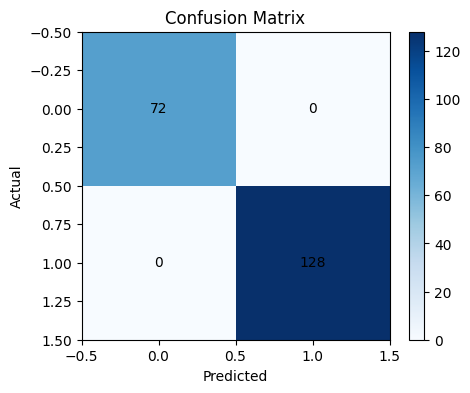

In [10]:
#confusion metrices
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

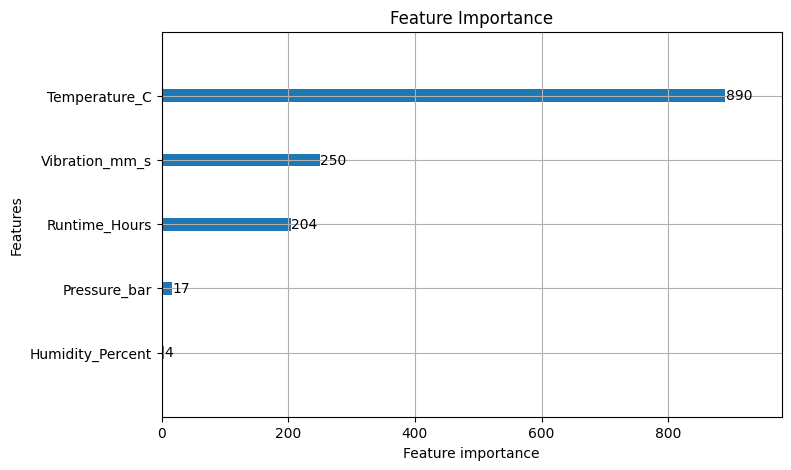

In [11]:
#feature importance
lgb.plot_importance(model, max_num_features=10, figsize=(8,5))
plt.title("Feature Importance")
plt.show()

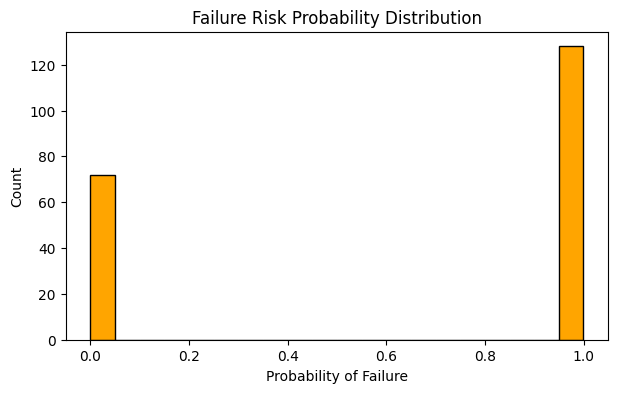

In [12]:
#Risk probability distribution

plt.figure(figsize=(7,4))
plt.hist(y_prob, bins=20, color="orange", edgecolor="black")
plt.title("Failure Risk Probability Distribution")
plt.xlabel("Probability of Failure")
plt.ylabel("Count")
plt.show()

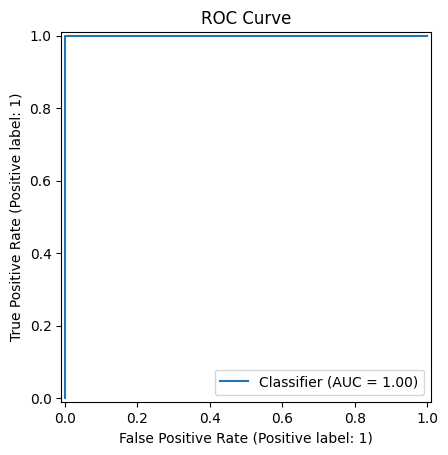

In [13]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

In [15]:
#real time prediction function
def predict_failure(temp, vibration, pressure, runtime, humidity, power, maintenance):
    data = np.array([[temp, vibration, pressure, runtime, humidity, power, maintenance]])
    pred = model.predict(data)[0]
    prob = model.predict_proba(data)[0][1]

    if pred == 1:
        print(f"HIGH FAILURE RISK (Probability: {prob:.2f})")
    else:
        print(f" NORMAL (Probability: {prob:.2f})")

In [20]:
#test prediction
predict_failure(
    temp=50,
    vibration=3.8,
    pressure=6,
    runtime=4200,
    humidity=20,
    power=40,
    maintenance=2
)

HIGH FAILURE RISK (Probability: 1.00)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
